# Initial EDA — Relational Data Wrangler & Fraud Sentinel

Explore `transactions.csv`, `accounts.csv`, and `customers.csv`: shapes, missingness, duplicates, anomalies, and join coverage.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

DATA_DIR = Path('.').resolve()
print('DATA_DIR:', DATA_DIR)

DATA_DIR: C:\Users\manan\OneDrive\Documents\Projects\azentio_hackathon


In [2]:
tx = pd.read_csv(DATA_DIR / 'transactions.csv')
ac = pd.read_csv(DATA_DIR / 'accounts.csv')
cu = pd.read_csv(DATA_DIR / 'customers.csv')

print('transactions:', tx.shape)
print('accounts:', ac.shape)
print('customers:', cu.shape)
print('\nTX columns:', list(tx.columns))
print('\nAC columns:', list(ac.columns))
print('\nCU columns:', list(cu.columns))

transactions: (1000, 29)
accounts: (178, 21)
customers: (124, 26)

TX columns: ['transaction_id', 'account_id', 'customer_id', 'transaction_timestamp', 'transaction_hour', 'is_weekend', 'amount', 'currency', 'transaction_type', 'channel', 'status', 'merchant_id', 'merchant_name', 'merchant_category', 'merchant_city', 'merchant_country', 'device_id', 'device_type', 'is_new_device', 'ip_address', 'auth_method', 'is_card_present', 'is_foreign_transaction', 'distance_from_home_km', 'time_since_prev_txn_mins', 'txn_count_last_24h', 'txn_count_last_7d', 'amount_to_account_avg_ratio', 'balance_after_txn']

AC columns: ['account_id', 'customer_id', 'account_type', 'account_status', 'currency', 'open_date', 'close_date', 'branch_code', 'branch_city', 'current_balance', 'avg_monthly_balance_6m', 'credit_limit', 'credit_utilization_pct', 'overdraft_enabled', 'card_type', 'is_joint_account', 'num_linked_devices', 'mobile_banking_enrolled', 'last_login_date', 'avg_monthly_txn_count', 'account_tier'

## 1. Head samples & dtypes

In [3]:
display(tx.head(3))
display(ac.head(3))
display(cu.head(3))
print('\n--- dtypes: transactions ---')
print(tx.dtypes)
print('\n--- dtypes: accounts ---')
print(ac.dtypes)
print('\n--- dtypes: customers ---')
print(cu.dtypes)

,transaction_id,account_id,customer_id,transaction_timestamp,transaction_hour,is_weekend,amount,currency,transaction_type,channel,status,merchant_id,merchant_name,merchant_category,merchant_city,merchant_country,device_id,device_type,is_new_device,ip_address,auth_method,is_card_present,is_foreign_transaction,distance_from_home_km,time_since_prev_txn_mins,txn_count_last_24h,txn_count_last_7d,amount_to_account_avg_ratio,balance_after_txn
0,TXN_0000796,ACC_000096,CUST_00069,2026-08-13 06:18:18,6,0,25.0,INR,NaN,INTERNET_BANKING,SUCCESS,MER_8691,NEFT Beneficiary,FUND_TRANSFER,Kolkata,IN,DEV_426304,NaN,1,49.57.192.223,BIOMETRIC,0,0,0.1,NaN,0,0,NaN,32219.78
1,TXN_0000974,ACC_000141,CUST_00096,2026-09-17 10:04:21,10,0,22574.7,INR,PURCHASE,POS,SUCCESS,MER_6761,Luxury Goods Direct,Jewellery,Mysuru,IN,DEV_789922,POS Terminal,0,NaN,PIN,1,FALSE,692.1,177.0,1,1,7.321,-2882.84
2,TXN_0000795,ACC_000122,CUST_00086,2026-08-13 03:03:52,3,0,5166.58,INR,PAYMENT,INTERNET_BANKING,NaN,MER_9568,UPI P2P Transfer,P2P_TRANSFER,Kochi,IN,DEV_308665,Android,0,49.45.37.237,BIOMETRIC,0,N,12.6,405.0,1,1,0.373,-5934.46


,account_id,customer_id,account_type,account_status,currency,open_date,close_date,branch_code,branch_city,current_balance,avg_monthly_balance_6m,credit_limit,credit_utilization_pct,overdraft_enabled,card_type,is_joint_account,num_linked_devices,mobile_banking_enrolled,last_login_date,avg_monthly_txn_count,account_tier
0,ACC_000001,CUST_00001,NRE,ACTIVE,INR,2016-08-26,NaN,BR122,Gurugram,33507.22,22831.70,0.0,0.0,Y,GOLD,0,2,Y,2026-07-20,15,SILVER
1,ACC_000002,CUST_00001,SAVINGS,ACTIVE,INR,2019-03-31,NaN,BR119,Gurugram,25171.02,32699.45,0.0,0.0,N,CLASSIC,0,1,Y,2026-06-15,18,SILVER
2,ACC_000003,CUST_00002,SAVINGS,DORMANT,INR,2022-03-24,NaN,BR122,Gurugram,13569.59,8583.40,0.0,0.0,N,CLASSIC,0,1,Y,2026-07-23,29,SILVER


,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,city,state,country,postal_code,occupation,annual_income,marital_status,education_level,employment_status,customer_since,customer_segment,kyc_status,risk_rating,is_politically_exposed,preferred_channel,email_verified,phone_verified,num_complaints_last_year
0,CUST_00001,Krishna,Sharma,M,1985-05-26,41,krishna.sharma31@gmail.com,+91-6939042955,Gurugram,Haryana,IN,741262,NaN,355047.0,Married,Diploma,NaN,2024-11-26,PREMIUM,VERIFIED,MEDIUM,0,Phone Banking,Y,Y,1
1,CUST_00002,Anika,Fernandes,M,2008-08-31,18,anika.fernandes907@outlook.com,+91-8479708607,Gurugram,Haryana,IN,182933,NaN,101869.0,NaN,NaN,EMPLOYED,2020-06-15,RETAIL,VERIFIED,LOW,0,Phone Banking,Y,Y,1
2,CUST_00003,Siddharth,Rao,F,1989-03-17,37,siddharth.rao235@gmail.com,+91-9457645390,Indore,Madhya Pradesh,IN,390746,NaN,443684.0,Married,Diploma,RETIRED,2016-02-03,RETAIL,VERIFIED,MEDIUM,0,Internet Banking,Y,Y,0



--- dtypes: transactions ---
transaction_id                     str
account_id                         str
customer_id                        str
transaction_timestamp              str
transaction_hour                 int64
is_weekend                       int64
amount                             str
currency                           str
transaction_type                   str
channel                            str
status                             str
merchant_id                        str
merchant_name                      str
merchant_category                  str
merchant_city                      str
merchant_country                   str
device_id                          str
device_type                        str
is_new_device                    int64
ip_address                         str
auth_method                        str
is_card_present                  int64
is_foreign_transaction             str
distance_from_home_km          float64
time_since_prev_txn_mins       flo

## 2. Missing / empty / N-A style values

In [4]:
NA_TOKENS = {'', 'N/A', 'NA', 'NULL', 'NONE', '-', 'NOT_AVAILABLE'}

def missing_report(df, name):
    rows = []
    for c in df.columns:
        s = df[c]
        nulls = int(s.isna().sum())
        empty = 0
        if s.dtype == object or str(s.dtype).startswith('string'):
            empty = int(s.astype(str).str.strip().str.upper().isin(NA_TOKENS).sum())
        total = nulls + empty
        if total:
            rows.append({'column': c, 'null': nulls, 'empty_or_token': empty, 'total_bad': total, 'pct': round(100 * total / len(df), 2)})
    out = pd.DataFrame(rows).sort_values('total_bad', ascending=False)
    print(f'\n=== {name}: {len(df)} rows ===')
    display(out if len(out) else pd.DataFrame({'msg': ['no missing-like values']}))
    return out

miss_tx = missing_report(tx, 'transactions')
miss_ac = missing_report(ac, 'accounts')
miss_cu = missing_report(cu, 'customers')


=== transactions: 1000 rows ===


,column,null,empty_or_token,total_bad,pct
10,ip_address,585,0,585,58.5
12,time_since_prev_txn_mins,156,0,156,15.6
13,amount_to_account_avg_ratio,156,0,156,15.6
11,auth_method,144,0,144,14.4
9,device_type,99,0,99,9.9
6,merchant_category,83,0,83,8.3
8,device_id,79,0,79,7.9
3,transaction_type,75,0,75,7.5
4,channel,73,0,73,7.3
7,merchant_city,62,0,62,6.2



=== accounts: 178 rows ===


,column,null,empty_or_token,total_bad,pct
2,close_date,177,0,177,99.44
3,branch_code,19,0,19,10.67
6,card_type,18,0,18,10.11
4,branch_city,14,0,14,7.87
1,account_status,11,0,11,6.18
7,account_tier,8,0,8,4.49
0,account_type,6,0,6,3.37
5,overdraft_enabled,6,0,6,3.37



=== customers: 124 rows ===


,column,null,empty_or_token,total_bad,pct
4,marital_status,18,0,18,14.52
9,risk_rating,18,0,18,14.52
10,preferred_channel,14,0,14,11.29
2,occupation,12,0,12,9.68
5,education_level,10,0,10,8.06
6,employment_status,9,0,9,7.26
0,gender,7,0,7,5.65
3,annual_income,7,0,7,5.65
8,kyc_status,6,0,6,4.84
1,phone_number,3,0,3,2.42


## 3. Duplicates & ID uniqueness

In [5]:
print('duplicate transaction_id:', tx['transaction_id'].duplicated().sum())
print('duplicate account_id:', ac['account_id'].duplicated().sum())
print('duplicate customer_id:', cu['customer_id'].duplicated().sum())
print('exact duplicate TX rows:', tx.duplicated().sum())

dup_ids = tx.loc[tx['transaction_id'].duplicated(keep=False), 'transaction_id'].unique()
print('conflicting txn id groups:', len(dup_ids))
if len(dup_ids):
    sample_id = dup_ids[0]
    display(tx[tx['transaction_id'] == sample_id])

duplicate transaction_id: 12
duplicate account_id: 0
duplicate customer_id: 0
exact duplicate TX rows: 12
conflicting txn id groups: 12


,transaction_id,account_id,customer_id,transaction_timestamp,transaction_hour,is_weekend,amount,currency,transaction_type,channel,status,merchant_id,merchant_name,merchant_category,merchant_city,merchant_country,device_id,device_type,is_new_device,ip_address,auth_method,is_card_present,is_foreign_transaction,distance_from_home_km,time_since_prev_txn_mins,txn_count_last_24h,txn_count_last_7d,amount_to_account_avg_ratio,balance_after_txn
29,TXN_0000570,ACC_000083,CUST_00059,2026-07-04 16:39:17,16,1,1483.25,INR,PURCHASE,ONLINE,SUCCESS,MER_9326,Flipkart,ECOMMERCE,Kolkata,IN,NaN,Android,1,49.54.86.181,3DS,0,no,5.1,43601.15,0,0,1.004,8373.16
134,TXN_0000570,ACC_000083,CUST_00059,2026-07-04 16:39:17,16,1,1483.25,INR,PURCHASE,ONLINE,SUCCESS,MER_9326,Flipkart,ECOMMERCE,Kolkata,IN,NaN,Android,1,49.54.86.181,3DS,0,no,5.1,43601.15,0,0,1.004,8373.16


## 4. Amount & timestamp anomalies (transactions)

In [6]:
def try_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.upper() in NA_TOKENS:
        return np.nan
    s = re.sub(r'(?i)^INR\s*', '', s).replace(',', '').strip()
    try:
        return float(s)
    except Exception:
        return np.nan

raw_amt = tx['amount'].astype(str)
weird_amt = tx[~raw_amt.str.match(r'^-?\d+(\.\d+)?$', na=False)]
print('non-plain-numeric amount samples:')
display(weird_amt[['transaction_id', 'amount']].head(15))
print('count weird amounts:', len(weird_amt))

tx['_amount_num'] = tx['amount'].map(try_float)
print('parsed amount describe:')
display(tx['_amount_num'].describe())

ts = tx['transaction_timestamp'].astype(str)
print('\ntimestamp pattern counts:')
patterns = {
    'ISO_space': ts.str.match(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$', na=False),
    'ISO_T': ts.str.match(r'\d{4}-\d{2}-\d{2}T', na=False),
    'DMY_slash': ts.str.match(r'\d{2}/\d{2}/\d{4}', na=False),
    'MDY_dash': ts.str.match(r'\d{2}-\d{2}-\d{4}', na=False),
    'NOT_AVAILABLE': ts.str.upper().eq('NOT_AVAILABLE'),
    'empty': ts.str.strip().isin({'', 'nan', 'None'}),
}
for k, m in patterns.items():
    print(f'  {k}: {int(m.sum())}')

non-plain-numeric amount samples:


,transaction_id,amount
69,TXN_0000459,NaN
80,TXN_0000109,NaN
126,TXN_0000462,INR 62146.26
200,TXN_0000794,"41,677.41"
285,TXN_0000744,INR 1056.43
292,TXN_0000038,"2,424.92"
369,TXN_0000852,"98,935.74"
477,TXN_0000950,INR 771.41
482,TXN_0000334,NaN
532,TXN_0000425,"1,958.46"


count weird amounts: 22
parsed amount describe:


count       995.000000
mean       9708.977809
std       28230.787826
min      -63866.440000
25%         606.305000
50%        1888.500000
75%        8133.680000
max      616242.430000
Name: _amount_num, dtype: float64


timestamp pattern counts:
  ISO_space: 910
  ISO_T: 15
  DMY_slash: 53
  MDY_dash: 12
  NOT_AVAILABLE: 3
  empty: 0


## 5. Categorical messiness & bool encodings

In [7]:
for col in ['transaction_type', 'channel', 'status', 'merchant_category', 'is_foreign_transaction']:
    print(f'\n--- {col} (top 12) ---')
    print(tx[col].astype(str).value_counts(dropna=False).head(12))


--- transaction_type (top 12) ---
transaction_type
PURCHASE       609
TRANSFER        82
NaN             75
PAYMENT         54
WITHDRAWAL      51
  PURCHASE      34
Purchase        34
purchase        21
Payment          8
  TRANSFER       6
  PAYMENT        6
Transfer         6
Name: count, dtype: int64

--- channel (top 12) ---
channel
POS                 408
MOBILE_APP          162
ONLINE              112
NaN                  73
INTERNET_BANKING     59
ATM                  47
  POS                27
Pos                  22
Mobile App           14
  MOBILE_APP         13
mobile_app           13
pos                   9
Name: count, dtype: int64

--- status (top 12) ---
status
SUCCESS       784
NaN            46
  SUCCESS      45
success        37
Success        35
FAILED         32
REVERSED       11
PENDING         6
  FAILED        1
Failed          1
failed          1
  PENDING       1
Name: count, dtype: int64

--- merchant_category (top 12) ---
merchant_category
NaN               

## 6. Accounts & customers snapshots

In [8]:
print('account_type:\n', ac['account_type'].value_counts(dropna=False))
print('\naccount_status:\n', ac['account_status'].value_counts(dropna=False))
print('\ncredit_limit describe:')
display(pd.to_numeric(ac['credit_limit'], errors='coerce').describe())

print('\nkyc_status:\n', cu['kyc_status'].value_counts(dropna=False))
print('\nrisk_rating:\n', cu['risk_rating'].value_counts(dropna=False))
print('\nPEP:\n', cu['is_politically_exposed'].value_counts(dropna=False))

account_type:
 account_type
SAVINGS        77
SALARY         38
CURRENT        31
CREDIT_CARD    20
NRE             6
NaN             6
Name: count, dtype: int64

account_status:
 account_status
ACTIVE     149
DORMANT     14
NaN         11
FROZEN       3
CLOSED       1
Name: count, dtype: int64

credit_limit describe:


count        178.000000
mean       52247.191011
std       181473.895394
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max      1000000.000000
Name: credit_limit, dtype: float64


kyc_status:
 kyc_status
VERIFIED    97
PENDING     12
EXPIRED      8
NaN          6
REJECTED     1
Name: count, dtype: int64

risk_rating:
 risk_rating
LOW       59
MEDIUM    26
HIGH      21
NaN       18
Name: count, dtype: int64

PEP:
 is_politically_exposed
0    122
1      2
Name: count, dtype: int64


## 7. Referential integrity (joins)

In [9]:
acct_ids = set(ac['account_id'])
cust_ids = set(cu['customer_id'])

orphan_acct = (~tx['account_id'].isin(acct_ids)).sum()
missing_cust = tx['customer_id'].isna() | tx['customer_id'].astype(str).str.strip().eq('')
orphan_cust = (~tx.loc[~missing_cust, 'customer_id'].isin(cust_ids)).sum()
acct_orphan_cust = (~ac['customer_id'].isin(cust_ids)).sum()

print('TX account_id not in accounts:', int(orphan_acct))
print('TX missing customer_id:', int(missing_cust.sum()))
print('TX customer_id not in customers (when present):', int(orphan_cust))
print('AC customer_id not in customers:', int(acct_orphan_cust))

# recoverability of missing customer via account
map_ac = ac.set_index('account_id')['customer_id']
recovered = tx.loc[missing_cust, 'account_id'].map(map_ac)
print('missing customer recoverable via account:', int(recovered.notna().sum()), '/', int(missing_cust.sum()))

TX account_id not in accounts: 8
TX missing customer_id: 8
TX customer_id not in customers (when present): 0
AC customer_id not in customers: 0
missing customer recoverable via account: 0 / 8


## 8. High-risk signal peek (pre-rules)

In [10]:
print('merchant_country top:')
print(tx['merchant_country'].value_counts().head(15))

print('\nmerchant_name contains CRYPTO/WIRE/LUXURY/QUICKCASH:')
name_u = tx['merchant_name'].astype(str).str.upper()
for kw in ['CRYPTO', 'WIRE', 'LUXURY', 'QUICKCASH']:
    print(f'  {kw}:', int(name_u.str.contains(kw, na=False).sum()))

dist = pd.to_numeric(tx['distance_from_home_km'], errors='coerce')
print('\ndistance_from_home_km describe:')
display(dist.describe())
print('distance > 500:', int((dist > 500).sum()))
print('distance > 5000:', int((dist > 5000).sum()))

merchant_country top:
merchant_country
IN    917
AE     13
PA     11
RU      9
NG      9
GB      9
RO      8
PH      7
SG      7
ID      6
UA      4
Name: count, dtype: int64

merchant_name contains CRYPTO/WIRE/LUXURY/QUICKCASH:
  CRYPTO: 16
  WIRE: 16
  LUXURY: 28
  QUICKCASH: 16

distance_from_home_km describe:


count     1000.000000
mean       694.769600
std       2000.917522
min          0.000000
25%          4.100000
50%          8.700000
75%        208.900000
max      11939.700000
Name: distance_from_home_km, dtype: float64

distance > 500: 211
distance > 5000: 55


## 9. Plots

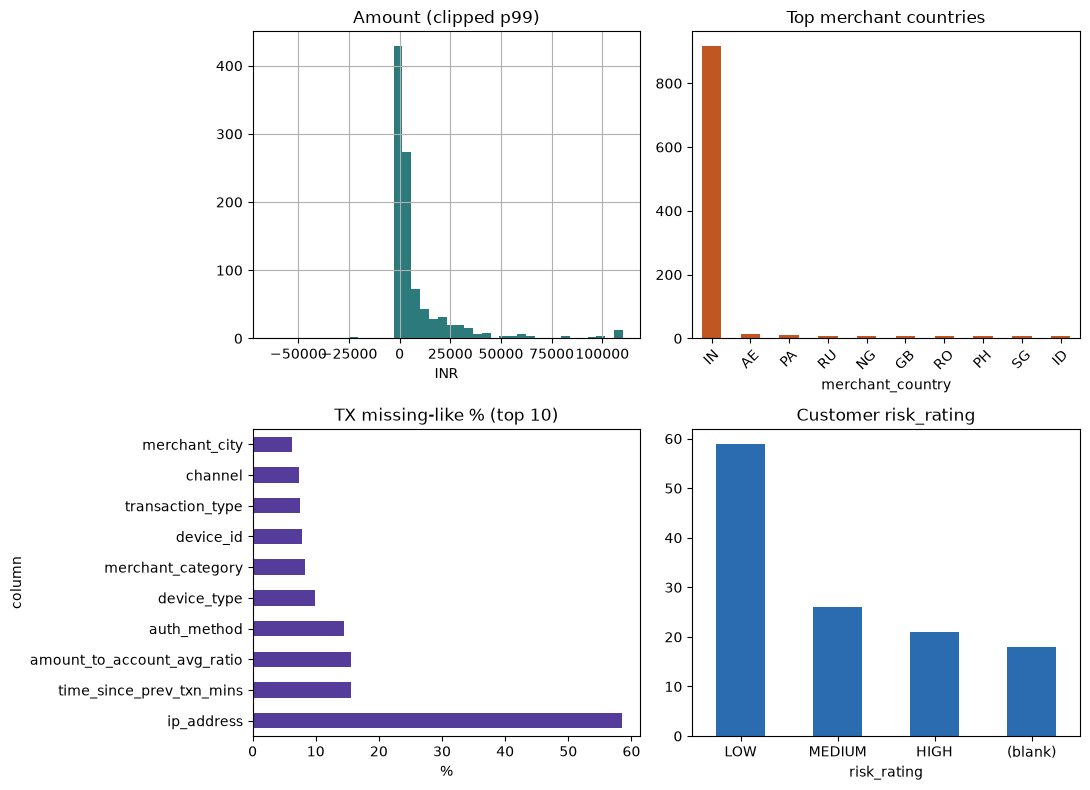

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
tx['_amount_num'].dropna().clip(upper=tx['_amount_num'].quantile(0.99)).hist(bins=40, ax=ax, color='#2c7a7b')
ax.set_title('Amount (clipped p99)')
ax.set_xlabel('INR')

ax = axes[0, 1]
tx['merchant_country'].value_counts().head(10).plot(kind='bar', ax=ax, color='#c05621')
ax.set_title('Top merchant countries')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 0]
miss_tx.head(10).set_index('column')['pct'].plot(kind='barh', ax=ax, color='#553c9a')
ax.set_title('TX missing-like % (top 10)')
ax.set_xlabel('%')

ax = axes[1, 1]
cu['risk_rating'].fillna('(blank)').astype(str).str.strip().replace('', '(blank)').value_counts().plot(kind='bar', ax=ax, color='#2b6cb0')
ax.set_title('Customer risk_rating')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 10. Notes column / injection text check

Hackathon brief mentions injection in transaction notes; confirm whether such a column exists.

In [12]:
note_like = [c for c in tx.columns if re.search(r'note|remark|memo|comment|narrat|desc', c, re.I)]
print('note-like columns in transactions:', note_like if note_like else 'NONE')

inj = re.compile(r'ignore\s+(previous|all)|jailbreak|system\s+prompt|classify\s+this', re.I)
hits = 0
for c in tx.select_dtypes(include=['object', 'string']).columns:
    n = 0
    for v in tx[c].tolist():
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        s = str(v)
        if s.lower() == 'nan':
            continue
        if inj.search(s):
            n += 1
    if n:
        print(f'  injection-like hits in {c}: {n}')
    hits += n
print('total injection-like cell hits:', hits)

note-like columns in transactions: NONE
total injection-like cell hits: 0


## EDA takeaways

- Three relational tables; join on `account_id` / `customer_id` with some orphans and missing customer IDs (often recoverable from accounts).
- Duplicate `transaction_id` rows need conflict-aware dedupe.
- Amounts and timestamps are messy (currency prefixes, commas, multiple date formats).
- Categoricals and foreign-transaction flags need canonicalization.
- No dedicated notes column in the provided CSV — scan all string fields for injection.
- High-risk cues already visible: foreign countries, large distance, crypto/wire/luxury merchants.